[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter1_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 1: Data, returns and indicators

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Data sources and data quality: EUR/RON from two sources, adjusted prices, price vs total return index.
- Simple and log returns, multi-period and portfolio returns, annualisation.
- Descriptive statistics and performance indicators: CAGR, volatility, Sharpe, Sortino, maximum drawdown, Calmar, volatility drag.
- Textbook: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Chapter 11.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Simple return $R_t = P_t/P_{t-1} - 1$; log return $r_t = \ln(P_t/P_{t-1})$.
- CAGR $= (P_T/P_0)^{1/Y} - 1$; drawdown $DD_t = P_t/\max_{s\le t}P_s - 1$; MDD $= \min_t DD_t$.
- Sharpe ratio $= \mu/\sigma$ (risk-free rate 0), annualised with $\sqrt{A}$; standard error of Lo (2002).
- Sortino ratio $= \mu/\sigma_D$ with the downside deviation $\sigma_D$; Calmar ratio $=$ CAGR$/|$MDD$|$.

In [5]:
START = '2015-01-01'
ASSETS = ['sp500', 'dax', 'bet', 'bettr', 'btc', 'tlv', 'snp', 'brd', 'snn', 'tgn']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'bettr': '#E67E22', 'btc': '#B5853F', 'tlv': '#2E7D32', 'snp': '#8E44AD', 'brd': '#DC3545', 'snn': '#1A3A6E', 'tgn': '#17A2B8', 'eurron': '#2E7D32', 'eurron_eodhd': '#CD0000'}
SCATTER = {'S&P 500': ('#1A3A6E', 'o'), 'DAX': ('#17A2B8', 'o'), 'BET': ('#CD0000', 'o'), 'BET-TR': ('#E67E22', 'o'), 'Bitcoin': ('#B5853F', '*'), 'Banca Transilvania': ('#2E7D32', 's'), 'OMV Petrom': ('#8E44AD', 's'), 'BRD': ('#DC3545', 's'), 'Nuclearelectrica': ('#6D4C41', 's'), 'Transgaz': ('#C2185B', 's')}


def simple_ret(p):
    """Simple (net) returns R_t = P_t / P_{t-1} - 1, as decimals."""
    return p.pct_change().dropna()


def log_ret(p):
    """Log returns r_t = ln(P_t / P_{t-1}), as decimals."""
    return np.log(p).diff().dropna()


def cagr(p):
    """Compound annual growth rate from the first and last price, over calendar years."""
    years = (p.index[-1] - p.index[0]).days / 365.25
    return (p.iloc[-1] / p.iloc[0]) ** (1 / years) - 1


def drawdown(p):
    """Drawdown DD_t = P_t / max_{s<=t} P_s - 1 (zero at a new maximum, negative below it)."""
    return p / p.cummax() - 1


def max_drawdown(p):
    """Maximum drawdown: depth, date of the previous peak, date of the trough, date of recovery (or None)."""
    dd = drawdown(p)
    trough = dd.idxmin()
    peak = p.loc[:trough].idxmax()
    after = p.loc[trough:]
    rec = after[after >= p.loc[peak]]
    return {'mdd': float(dd.min()), 'peak': peak.date().isoformat(), 'trough': trough.date().isoformat(),
            'recovery': rec.index[0].date().isoformat() if len(rec) else None}


def downside_deviation(R, target=0.0):
    """Downside deviation below a target: sqrt(mean(min(R - target, 0)^2)), over all observations."""
    return float(np.sqrt(np.mean(np.minimum(R - target, 0.0) ** 2)))


def sharpe_se(sr, n):
    """Standard error of a Sharpe ratio estimated from n i.i.d. returns (Lo, 2002): sqrt((1 + SR^2/2) / n)."""
    return float(np.sqrt((1 + 0.5 * sr ** 2) / n))


def performance(p, rf=0.0):
    """Performance indicators of one price series on its own calendar (annualised with its actual frequency)."""
    R, r = simple_ret(p), log_ret(p)
    q = periods_per_year(R)
    mu_a = R.mean() * q                                 # arithmetic annual mean of simple returns
    vol = R.std() * np.sqrt(q)                          # annualised volatility
    sr_d = (R.mean() - rf / q) / R.std()                # per-period Sharpe ratio
    sr = sr_d * np.sqrt(q)
    se = sharpe_se(sr_d, len(R)) * np.sqrt(q)
    sortino = (mu_a - rf) / (downside_deviation(R) * np.sqrt(q))
    m = max_drawdown(p)
    g = cagr(p)
    return {'n': len(R), 'obs_per_year': q, 'years': (p.index[-1] - p.index[0]).days / 365.25,
            'mean_arith': mu_a, 'mean_log': r.mean() * q, 'cagr': g, 'vol': vol,
            'drag': mu_a - r.mean() * q, 'half_var': 0.5 * vol ** 2,
            'sharpe': sr, 'sharpe_se': se, 'sharpe_lo': sr - 1.96 * se, 'sharpe_hi': sr + 1.96 * se,
            'sortino': sortino, 'mdd': m['mdd'], 'mdd_peak': m['peak'], 'mdd_trough': m['trough'],
            'mdd_recovery': m['recovery'], 'calmar': g / abs(m['mdd'])}


def describe(r):
    """Descriptive statistics of daily log returns (in %): moments, extremes and the precision of the mean."""
    q = periods_per_year(r)
    return {'n': len(r), 'obs_per_year': q, 'mean': r.mean(), 'sd': r.std(), 'skew': stats.skew(r),
            'exkurt': stats.kurtosis(r), 'min': r.min(), 'min_date': r.idxmin().date().isoformat(),
            'max': r.max(), 'max_date': r.idxmax().date().isoformat(), 'q01': r.quantile(0.01),
            'q99': r.quantile(0.99), 'ann_mean': r.mean() * q, 'ann_vol': r.std() * np.sqrt(q),
            'se_ann_mean': r.std() * np.sqrt(q) / np.sqrt(len(r) / q)}

## 1. Data quality

- Two EUR/RON series: the EODHD series and the official BNR reference rate.
- Banca Transilvania (TLV): the close jumps at corporate actions, the adjusted close does not.
- BET (price index) vs BET-TR (dividends reinvested).
- The last five daily bars (OHLCV) of TLV: look for suspicious rows.

In [6]:
def fig_eurron(save=True):
    """EUR/RON: daily log returns of the EODHD series and of the BNR reference rate, on common days."""
    x = pd.concat([load_close('eurron'), load_close('eurron_eodhd')], axis=1).dropna()
    r = 100 * np.log(x).diff().dropna()
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(r.index, r['eurron_eodhd'], color=COLORS['eurron_eodhd'], lw=0.7, label='EUR/RON series from EODHD')
    ax.plot(r.index, r['eurron'], color=COLORS['eurron'], lw=0.7, label='EUR/RON, BNR reference rate')
    ax.set_ylabel('Daily log return (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_eurron_check')
    d = (r['eurron_eodhd'] - r['eurron']).abs()
    q = periods_per_year(r)
    return {'n': len(r), 'days_diff_1pct': int((d > 1).sum()), 'vol_bnr': r['eurron'].std() * np.sqrt(q),
            'vol_eodhd': r['eurron_eodhd'].std() * np.sqrt(q), 'max_eodhd': r['eurron_eodhd'].abs().max(),
            'max_eodhd_date': r['eurron_eodhd'].abs().idxmax().date().isoformat(),
            'max_bnr': r['eurron'].abs().max(), 'max_bnr_date': r['eurron'].abs().idxmax().date().isoformat()}


def fig_tlv_adjusted(start=START, save=True):
    """Banca Transilvania: close vs adjusted close (log scale); the close jumps at corporate actions."""
    t = read_market('TLV.RO').loc[start:]
    t = t[t.index.dayofweek < 5]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(t.index, t['close'], color=COLORS['bet'], lw=1.1, label='Close (as traded)')
    ax.plot(t.index, t['adjusted_close'], color=COLORS['tlv'], lw=1.1, label='Adjusted close')
    ax.set_yscale('log')
    ax.set_ylabel('Price, RON (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_tlv_adjusted')
    rc, ra = np.log(t['close']).diff(), np.log(t['adjusted_close']).diff()
    d = (rc - ra).dropna()
    big = d.abs().idxmax()
    return {'jump_date': big.date().isoformat(), 'jump_close': 100 * rc.loc[big], 'jump_adj': 100 * ra.loc[big],
            'close_before': float(t['close'].shift(1).loc[big]), 'close_after': float(t['close'].loc[big]),
            'n_events_2pct': int((d.abs() > 0.02).sum())}


def fig_bet_bettr(save=True):
    """BET (price index) vs BET-TR (total return index, dividends reinvested), growth of 100."""
    x = pd.concat([load_close('bet', '2014-09-23'), load_close('bettr', '2014-09-23')], axis=1).dropna()
    idx = 100 * x / x.iloc[0]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(idx.index, idx['bet'], color=COLORS['bet'], lw=1.3, label='BET (price index)')
    ax.plot(idx.index, idx['bettr'], color=COLORS['bettr'], lw=1.3, label='BET-TR (dividends reinvested)')
    ax.set_ylabel('Value of 100 invested')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_bet_bettr')
    years = (x.index[-1] - x.index[0]).days / 365.25
    g = (x.iloc[-1] / x.iloc[0]) ** (1 / years) - 1
    return {'start': x.index[0].date().isoformat(), 'end_bet': float(idx['bet'].iloc[-1]),
            'end_bettr': float(idx['bettr'].iloc[-1]), 'cagr_bet': float(g['bet']), 'cagr_bettr': float(g['bettr'])}


def ohlc_last(symbol='TLV.RO', n=5):
    """The last n trading days of OHLCV data of one symbol (as traded, plus the adjusted close)."""
    t = read_market(symbol)
    t = t[(t.index.dayofweek < 5) & (t['volume'] > 0)].tail(n)
    return {d.date().isoformat(): {c: float(t.loc[d, c]) for c in ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']}
            for d in t.index}

{'n': 5154,
 'days_diff_1pct': 412,
 'vol_bnr': np.float64(4.50020252010574),
 'vol_eodhd': np.float64(13.418027157591853),
 'max_eodhd': 15.411399774941192,
 'max_eodhd_date': '2025-08-14',
 'max_bnr': 4.693575675985295,
 'max_bnr_date': '2008-10-06'}

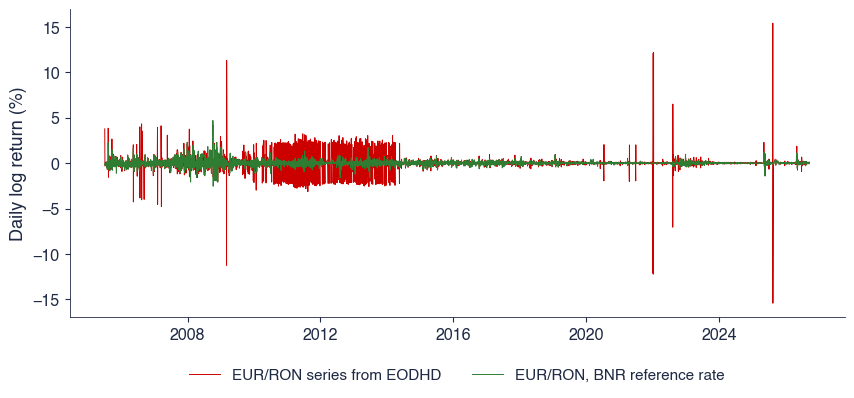

In [7]:
fig_eurron(save=False)

{'jump_date': '2022-08-16',
 'jump_close': np.float64(230.25898099640526),
 'jump_adj': np.float64(0.0),
 'close_before': 2.12,
 'close_after': 21.2001,
 'n_events_2pct': 24}

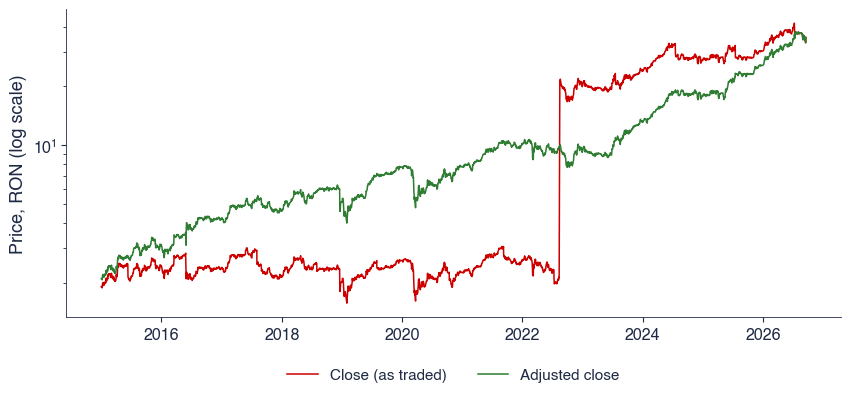

In [8]:
fig_tlv_adjusted(save=False)

{'start': '2014-09-23',
 'end_bet': 454.6286118744275,
 'end_bettr': 1004.7392891205482,
 'cagr_bet': 0.13466411861945438,
 'cagr_bettr': 0.21227128178275878}

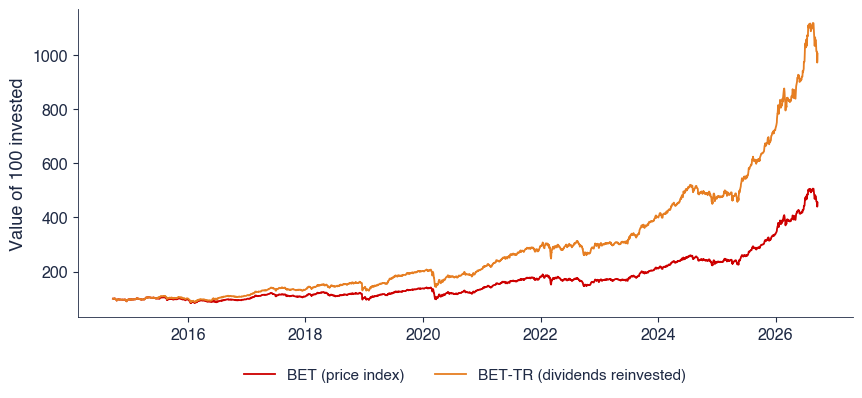

In [9]:
fig_bet_bettr(save=False)

In [10]:
pd.DataFrame(ohlc_last()).T

,open,high,low,close,adjusted_close,volume
2026-09-14,34.52,34.86,34.28,34.54,34.54,346819.0
2026-09-15,34.40,34.68,33.10,34.00,34.00,676653.0
2026-09-16,34.00,34.10,33.20,33.40,33.40,853078.0
2026-09-17,33.40,33.40,33.40,33.40,33.40,1084380.0
2026-09-18,34.22,35.80,34.22,35.50,35.50,1884988.0


## 2. Prices vs returns

- Prices trend; returns fluctuate around a stable level.
- The ADF (augmented Dickey-Fuller) test: $H_0$ unit root. We do not reject it for the log price, we reject it for the returns.

In [11]:
def fig_price_returns(save=True):
    """S&P 500 since 2000: price level (top) and daily log returns (bottom); ADF tests on both."""
    from statsmodels.tsa.stattools import adfuller
    p = load_close('sp500')
    r = 100 * log_ret(p)
    fig, ax = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
    ax[0].plot(p.index, p, color=COLORS['sp500'], lw=1.0, label='S&P 500 price')
    ax[0].set_ylabel('Index points')
    ax[1].plot(r.index, r, color=COLORS['bet'], lw=0.5, label='S&P 500 daily log return (%)')
    ax[1].set_ylabel('Log return (%)')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_price_returns')
    a_p = adfuller(np.log(p), regression='ct', autolag='AIC')
    a_r = adfuller(r, regression='c', autolag='AIC')
    return {'adf_price': a_p[0], 'p_price': a_p[1], 'adf_ret': a_r[0], 'p_ret': a_r[1],
            'crit5_ct': a_p[4]['5%'], 'crit5_c': a_r[4]['5%'], 'n': len(r),
            'first': p.index[0].date().isoformat()}

{'adf_price': np.float64(-2.081368977478584),
 'p_price': np.float64(0.5565126716047003),
 'adf_ret': np.float64(-14.264228928517241),
 'p_ret': np.float64(1.4095855864532848e-26),
 'crit5_ct': np.float64(-3.411147448160397),
 'crit5_c': np.float64(-2.86197290430069),
 'n': 6714,
 'first': '2000-01-03'}

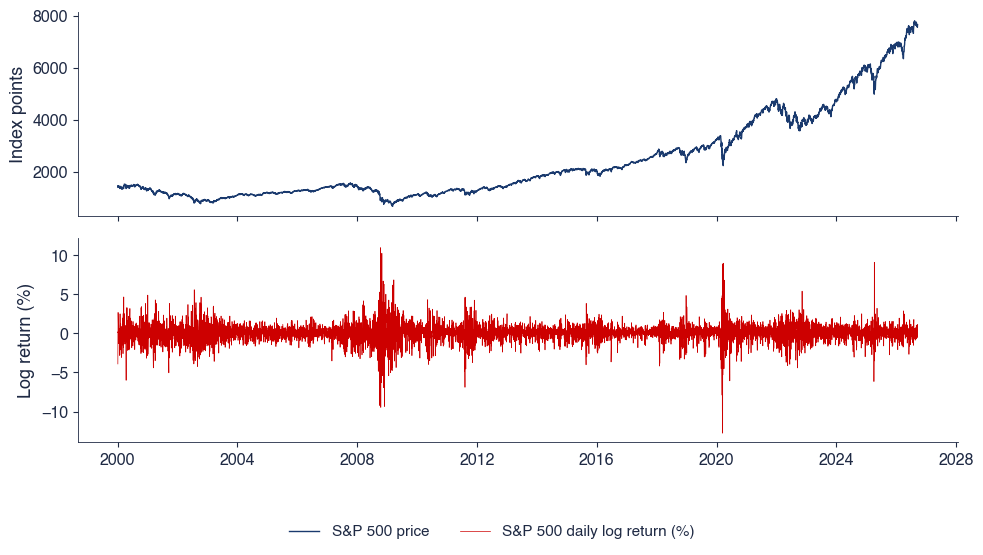

In [12]:
fig_price_returns(save=False)

## 3. Simple vs log returns

- $r = \ln(1+R) < R$; the gap is about $R^2/2$, negligible for daily data, large for crashes.

In [13]:
def fig_simple_log(save=True):
    """r = ln(1 + R) against R, with the largest daily moves of Bitcoin and the S&P 500 marked."""
    R = np.linspace(-0.6, 0.6, 400)
    fig, ax = plt.subplots(figsize=(8.6, 4.4))
    ax.plot(100 * R, 100 * R, color='black', lw=0.9, ls='--', label='r = R (45-degree line)')
    ax.plot(100 * R, 100 * np.log1p(R), color=COLORS['sp500'], lw=1.8, label='r = ln(1 + R)')
    out = {}
    for k, mk in [('btc', 'o'), ('sp500', 's')]:
        Rk = simple_ret(load_close(k))
        for lab, d in [('min', Rk.idxmin()), ('max', Rk.idxmax())]:
            x = Rk.loc[d]
            ax.scatter(100 * x, 100 * np.log1p(x), color=COLORS[k], marker=mk, s=45, zorder=3,
                       label=f'{LABELS[k]}, largest daily moves' if lab == 'min' else '_')
            out[f'{k}_{lab}'] = {'date': d.date().isoformat(), 'R': 100 * x, 'r': 100 * np.log1p(x)}
    ax.set_xlabel('Simple return R (%)')
    ax.set_ylabel('Log return r (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_simple_log')
    return out

{'btc_min': {'date': '2020-03-12',
  'R': np.float64(-37.169540528180534),
  'r': np.float64(-46.473020666317)},
 'btc_max': {'date': '2017-12-07',
  'R': np.float64(25.24716942763181),
  'r': np.float64(22.511895434132782)},
 'sp500_min': {'date': '2020-03-16',
  'R': np.float64(-11.984053972305631),
  'r': np.float64(-12.765218306533924)},
 'sp500_max': {'date': '2008-10-13',
  'R': np.float64(11.58003603122706),
  'r': np.float64(10.957195934756697)}}

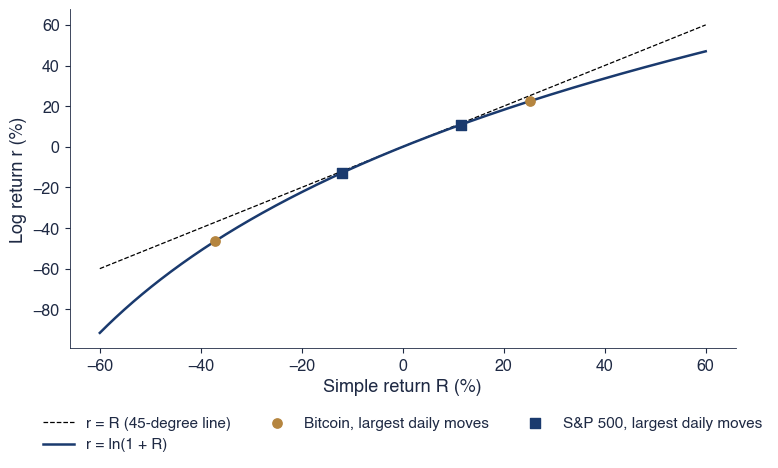

In [14]:
fig_simple_log(save=False)

## 4. Multi-period and portfolio returns

- Log returns add over time; simple returns add across assets.
- Growth of 100 since 2015 (log scale) and a 50/50 TLV-SNP portfolio rebalanced daily.

In [15]:
def fig_growth(names=('sp500', 'dax', 'bet', 'btc'), start=START, save=True):
    """Growth of 100 invested at the first common date (log scale): cumulative simple return of each series."""
    px = pd.concat([load_close(k, start) for k in names], axis=1).ffill().dropna()
    idx = 100 * px / px.iloc[0]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for k in names:
        ax.plot(idx.index, idx[k], color=COLORS[k], lw=1.3, label=LABELS[k])
    ax.set_yscale('log')
    ax.set_ylabel('Value of 100 invested (log scale)')
    st.legend_outside_bottom(ax, ncol=len(names), y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_growth')
    return {k: {'end': float(idx[k].iloc[-1]), 'cum_simple': float(idx[k].iloc[-1] / 100 - 1),
                'cum_log': float(np.log(idx[k].iloc[-1] / 100))} for k in names}


def portfolio_example(a='tlv', b='snp', w=0.5, start=START):
    """Two-stock portfolio (daily rebalanced to weights w, 1-w): exact simple return vs weighted log returns."""
    px = pd.concat([load_close(a, start), load_close(b, start)], axis=1).dropna()
    R = px.pct_change().dropna()
    r = np.log(px).diff().dropna()
    Rp = w * R[a] + (1 - w) * R[b]                     # exact for simple returns
    rp_exact = np.log1p(Rp)                            # exact portfolio log return
    rp_approx = w * r[a] + (1 - w) * r[b]              # weighted sum of log returns (approximation)
    err = 1e4 * (rp_exact - rp_approx)                 # in basis points
    years = (px.index[-1] - px.index[0]).days / 365.25
    wealth = (1 + Rp).prod()
    return {'n': len(Rp), 'mean_abs_err_bp': float(err.abs().mean()), 'max_err_bp': float(err.max()),
            'max_err_date': err.idxmax().date().isoformat(), 'cagr_port': float(wealth ** (1 / years) - 1),
            'cagr_a': cagr(px[a]), 'cagr_b': cagr(px[b]), 'wealth': float(wealth),
            'sum_exact': float(rp_exact.sum()), 'sum_approx': float(rp_approx.sum()), 'start': px.index[0].date().isoformat()}

{'sp500': {'end': 378.6289085312138,
  'cum_simple': 2.7862890853121383,
  'cum_log': 1.3313864062673064},
 'dax': {'end': 267.11319137436715,
  'cum_simple': 1.6711319137436713,
  'cum_log': 0.9825023203076592},
 'bet': {'end': 469.9256188269723,
  'cum_simple': 3.6992561882697235,
  'cum_log': 1.547404238376971},
 'btc': {'end': 29475.09098324568,
  'cum_simple': 293.7509098324568,
  'cum_log': 5.686130626206463}}

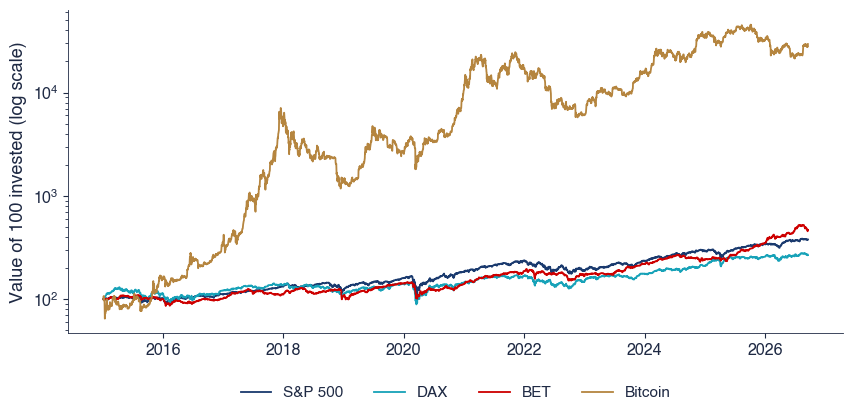

In [16]:
fig_growth(save=False)

In [17]:
portfolio_example()

{'n': 2455,
 'mean_abs_err_bp': 0.377677244560578,
 'max_err_bp': 13.898826733387617,
 'max_err_date': '2016-05-31',
 'cagr_port': 0.24452289383949566,
 'cagr_a': np.float64(0.2732115545913816),
 'cagr_b': np.float64(0.19737229711449533),
 'wealth': 12.963545294868767,
 'sum_exact': 2.5621412102171517,
 'sum_approx': 2.4694214466775297,
 'start': '2015-01-01'}

## 5. Annualisation and descriptive statistics

- Annual mean $= A\times$ mean, annual volatility $= \sqrt{A}\times$ s.d., $A$ = actual observations per year.
- Standard error of the annual mean $= \sigma_{year}/\sqrt{Y}$: it depends on the number of years only.
- Skewness, excess kurtosis and the worst day of each series.

In [18]:
def descriptive_table(names=ASSETS, start=START):
    rows = {LABELS[k]: describe(log_returns(k, start)) for k in names}
    return pd.DataFrame(rows).T


def fig_hist(names=('sp500', 'btc'), start=START, save=True):
    """Histograms of daily log returns vs the Normal density with the same mean and standard deviation."""
    fig, axes = plt.subplots(1, len(names), figsize=(10, 3.9))
    out = {}
    for ax, k in zip(axes, names):
        r = log_returns(k, start)
        lo, hi = r.quantile(0.001), r.quantile(0.999)
        x = np.linspace(lo, hi, 300)
        ax.hist(r.clip(lo, hi), bins=90, density=True, color=COLORS[k], alpha=0.55, label=f'{LABELS[k]} (histogram)')
        ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color='black', lw=1.3,
                label='Normal density, same mean and s.d.' if k == names[0] else '_')
        ax.set_xlabel('Daily log return (%)')
        ax.set_yticks([])
        within = float(np.mean(np.abs(r - r.mean()) <= r.std()))
        beyond3 = float(np.mean(np.abs(r - r.mean()) > 3 * r.std()))
        out[k] = {'within1sd': within, 'beyond3sd': beyond3, 'normal_beyond3sd': float(2 * stats.norm.sf(3)),
                  'normal_within1sd': float(1 - 2 * stats.norm.sf(1))}
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_hist_normal')
    return out


def fig_rolling_vol(names=('sp500', 'bet', 'btc'), start=START, window=250, save=True):
    """Rolling one-year annualised volatility of daily log returns (window of `window` observations)."""
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    for k in names:
        r = log_returns(k, start)
        q = periods_per_year(r)
        w = int(round(q)) if k == 'btc' else window
        v = r.rolling(w).std() * np.sqrt(q)
        ax.plot(v.index, v, color=COLORS[k], lw=1.2, label=LABELS[k])
        out[k] = {'min': float(v.min()), 'max': float(v.max()), 'max_date': v.idxmax().date().isoformat(),
                  'last': float(v.dropna().iloc[-1])}
    ax.set_ylabel('Annualised volatility (%)')
    st.legend_outside_bottom(ax, ncol=len(names), y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_rolling_vol_1y')
    return out

In [19]:
desc = descriptive_table()
desc[['n', 'obs_per_year', 'mean', 'sd', 'skew', 'exkurt', 'min', 'min_date', 'ann_mean', 'ann_vol', 'se_ann_mean']].round(3)

,n,obs_per_year,mean,sd,skew,exkurt,min,min_date,ann_mean,ann_vol,se_ann_mean
S&P 500,2943,251.504621,0.044612,1.115452,-0.643983,15.848795,-12.765218,2020-03-16,11.220193,17.689835,5.171323
DAX,2972,253.98292,0.032039,1.196694,-0.564807,9.9726,-13.05486,2020-03-12,8.137264,19.071522,5.575235
BET,2925,250.024865,0.052903,0.982848,-1.414259,17.846978,-11.892007,2018-12-19,13.226993,15.540961,4.543668
BET-TR,2925,250.024865,0.080014,0.978564,-1.432319,18.116562,-11.857201,2018-12-19,20.005394,15.473223,4.523863
Bitcoin,4278,365.335399,0.129752,3.488598,-0.731427,12.167352,-46.473021,2020-03-12,47.403092,66.680182,19.48598
Banca Transilvania,2677,228.772637,0.105681,1.685037,-0.554694,25.196398,-22.206746,2018-12-19,24.176855,25.48657,7.450566
OMV Petrom,2683,229.285388,0.078635,1.542242,-0.655085,9.233248,-14.978213,2020-03-09,18.029798,23.352901,6.826824
BRD,2695,230.310891,0.075177,1.607506,-0.506527,9.158353,-18.171837,2018-12-19,17.314159,24.395511,7.131613
Nuclearelectrica,2655,226.892548,0.11803,1.532602,0.294382,5.199109,-9.421287,2020-03-09,26.780076,23.085515,6.748658
Transgaz,2560,218.773982,0.090918,1.55216,0.010286,5.257178,-10.134888,2018-12-19,19.890446,22.958011,6.711384


{'sp500': {'within1sd': 0.7957866123003737,
  'beyond3sd': 0.013931362555215767,
  'normal_beyond3sd': 0.002699796063260186,
  'normal_within1sd': 0.6826894921370859},
 'btc': {'within1sd': 0.7954651706404862,
  'beyond3sd': 0.01846657316503039,
  'normal_beyond3sd': 0.002699796063260186,
  'normal_within1sd': 0.6826894921370859}}

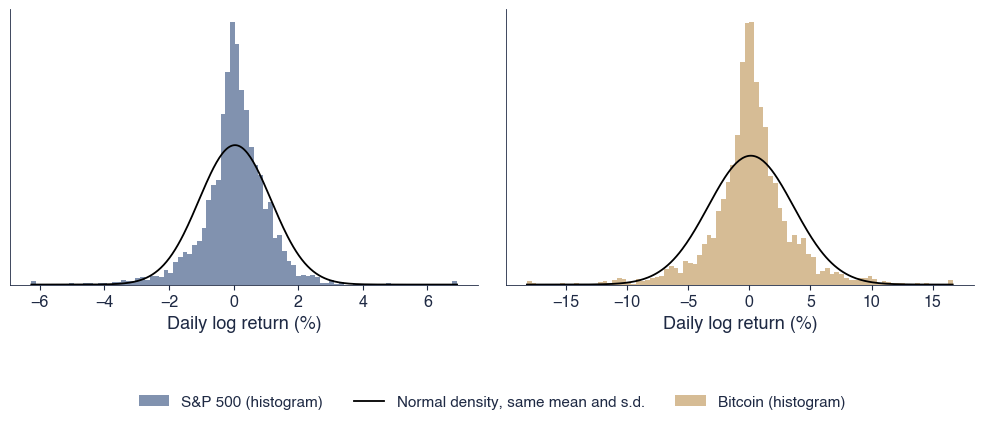

In [20]:
fig_hist(save=False)

{'sp500': {'min': 6.682744148109478,
  'max': 35.020493524754436,
  'max_date': '2021-02-08',
  'last': 12.923332118475074},
 'bet': {'min': 8.694265732626251,
  'max': 25.109014319580876,
  'max_date': '2021-01-21',
  'last': 16.022691398214427},
 'btc': {'min': 41.05047630035344,
  'max': 105.7700003218083,
  'max_date': '2018-05-11',
  'last': 45.07856982009644}}

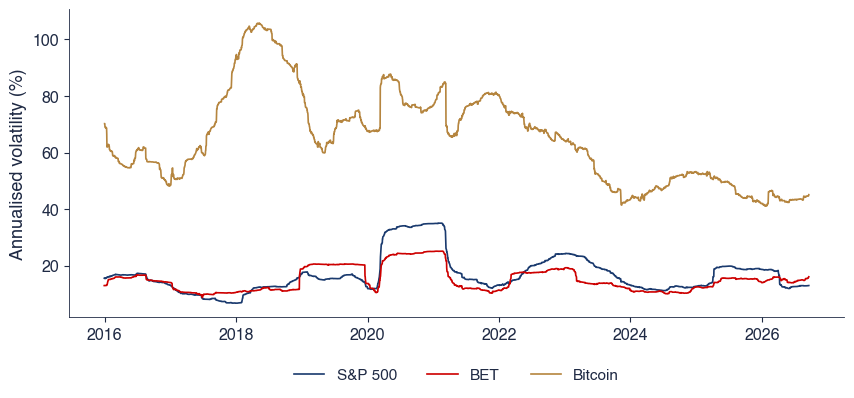

In [21]:
fig_rolling_vol(save=False)

## 6. Performance indicators

- CAGR, volatility, Sharpe (with its 95% interval), Sortino, MDD with dates, Calmar, volatility drag.

In [22]:
def performance_table(names=ASSETS, start=START):
    rows = {LABELS[k]: performance(load_close(k, start)) for k in names}
    return pd.DataFrame(rows).T


def fig_drawdowns(save=True):
    """Drawdown (underwater) curves over each series' full history: S&P 500, BET, Bitcoin."""
    series = {'sp500': load_close('sp500'), 'bet': load_close('bet', '1997-09-19'), 'btc': load_close('btc')}
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    for k, p in series.items():
        dd = 100 * drawdown(p)
        ax.plot(dd.index, dd, color=COLORS[k], lw=1.0, label=LABELS[k])
        m = max_drawdown(p)
        m['first'] = p.index[0].date().isoformat()
        m['under_share'] = float((drawdown(p) < -0.20).mean())
        out[k] = m
    ax.set_ylabel('Drawdown from the previous peak (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_drawdowns')
    return out


def fig_risk_return(perf, save=True):
    """Annualised volatility vs CAGR, one point per asset, 2015-2026."""
    fig, ax = plt.subplots(figsize=(8.6, 4.4))
    for lab in perf.index:
        c, mk = SCATTER[lab]
        ax.scatter(100 * perf.loc[lab, 'vol'], 100 * perf.loc[lab, 'cagr'], s=80 if mk == '*' else 50,
                   color=c, marker=mk, zorder=3, label=lab)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('Annualised volatility (%)')
    ax.set_ylabel('CAGR (%)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_risk_return')


def fig_sharpe_ci(perf, save=True):
    """Sharpe ratios (risk-free rate 0) with 95% intervals from the Lo (2002) standard error."""
    p = perf.sort_values('sharpe')
    fig, ax = plt.subplots(figsize=(9, 4.4))
    y = np.arange(len(p))
    sr = p['sharpe'].astype(float)
    ax.errorbar(sr, y, xerr=1.96 * p['sharpe_se'].astype(float), fmt='o', color=COLORS['sp500'],
                ecolor=COLORS['bet'], capsize=3, label='Sharpe ratio with 95% interval')
    ax.axvline(0, color='black', lw=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(p.index)
    ax.set_xlabel('Annualised Sharpe ratio (risk-free rate 0)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_sharpe_ci')


def fig_vol_drag(perf, save=True):
    """Volatility drag: arithmetic minus log annual mean, against half the annual variance (one point per asset)."""
    fig, ax = plt.subplots(figsize=(8.6, 4.4))
    x = 100 * perf['half_var'].astype(float)
    y = 100 * perf['drag'].astype(float)
    lo, hi = min(x.min(), y.min()) * 0.8, max(x.max(), y.max()) * 1.25
    ax.plot([lo, hi], [lo, hi], color='black', lw=0.9, ls='--', label='drag = sigma^2 / 2')
    for lab, xv, yv in zip(perf.index, x, y):
        c, mk = SCATTER[lab]
        ax.scatter(xv, yv, s=70 if mk == '*' else 45, color=c, marker=mk, zorder=3, label=lab)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Half the annual variance, sigma^2/2 (% per year, log scale)')
    ax.set_ylabel('Arithmetic minus log mean (% per year)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch1_vol_drag')

In [23]:
perf = performance_table()
perf[['cagr', 'vol', 'sharpe', 'sharpe_se', 'sortino', 'mdd', 'mdd_peak', 'mdd_trough', 'calmar', 'drag', 'half_var']].round(3)

,cagr,vol,sharpe,sharpe_se,sortino,mdd,mdd_peak,mdd_trough,calmar,drag,half_var
S&P 500,0.118651,0.176458,0.724484,0.292485,1.018259,-0.33925,2020-02-19,2020-03-23,0.349745,0.015639,0.015569
DAX,0.084713,0.190229,0.523229,0.292412,0.731757,-0.387794,2020-02-19,2020-03-18,0.218449,0.018161,0.018094
BET,0.141381,0.154495,0.9342,0.292622,1.281454,-0.31124,2020-01-23,2020-03-23,0.45425,0.012059,0.011934
BET-TR,0.221411,0.153855,1.378291,0.292922,1.923537,-0.311154,2020-01-23,2020-03-23,0.711581,0.012003,0.011836
Bitcoin,0.606279,0.662307,1.049848,0.292451,1.546617,-0.83399,2017-12-16,2018-12-15,0.726961,0.221291,0.219325
Banca Transilvania,0.273212,0.254521,1.07778,0.292704,1.590786,-0.388996,2020-01-15,2020-03-23,0.70235,0.032549,0.03239
OMV Petrom,0.197372,0.232716,0.891914,0.292586,1.286498,-0.454419,2015-01-01,2016-02-12,0.43434,0.027265,0.027078
BRD,0.188842,0.243352,0.833781,0.292554,1.20901,-0.356124,2022-02-11,2022-09-29,0.53027,0.02976,0.02961
Nuclearelectrica,0.306759,0.231772,1.271384,0.292853,2.003392,-0.368432,2015-07-02,2016-05-11,0.832609,0.026871,0.026859
Transgaz,0.219839,0.229933,0.980144,0.292654,1.490359,-0.448294,2019-12-09,2022-03-07,0.49039,0.026463,0.026435


{'sp500': {'mdd': -0.5677538894035716,
  'peak': '2007-10-09',
  'trough': '2009-03-09',
  'recovery': '2013-03-28',
  'first': '2000-01-03',
  'under_share': 0.27252419955323903},
 'bet': {'mdd': -0.8254844135943752,
  'peak': '2007-07-24',
  'trough': '2009-02-25',
  'recovery': '2021-03-16',
  'first': '1997-09-19',
  'under_share': 0.5647432357813362},
 'btc': {'mdd': -0.8339900920034271,
  'peak': '2017-12-16',
  'trough': '2018-12-15',
  'recovery': '2020-11-30',
  'first': '2014-09-17',
  'under_share': 0.6586088939566704}}

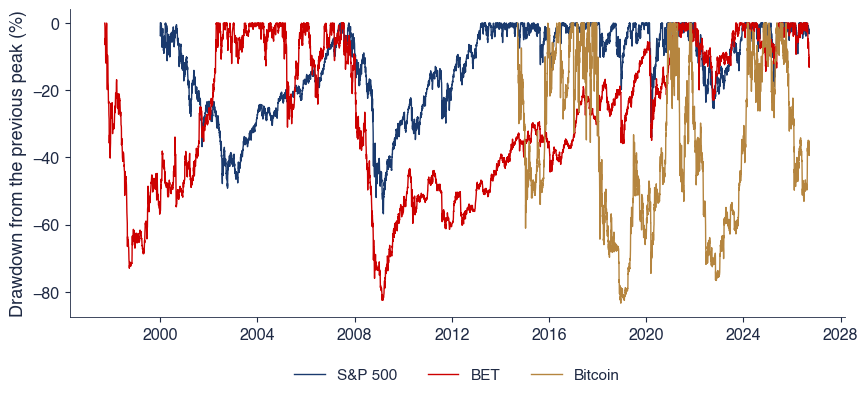

In [24]:
fig_drawdowns(save=False)

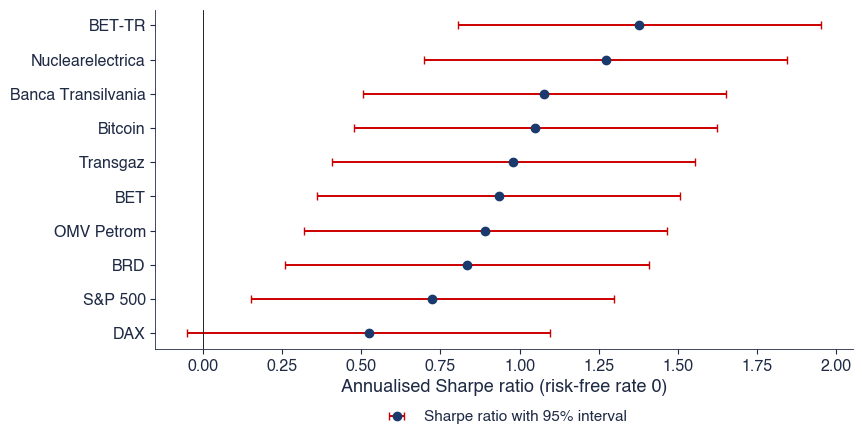

In [25]:
fig_sharpe_ci(perf, save=False)

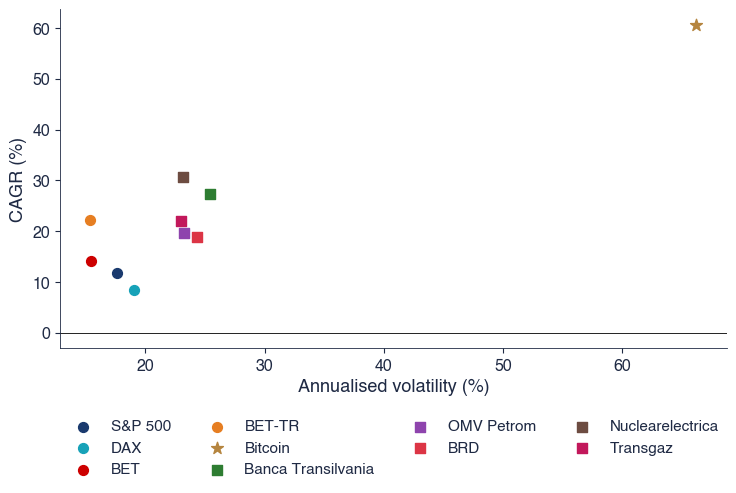

In [26]:
fig_risk_return(perf, save=False)

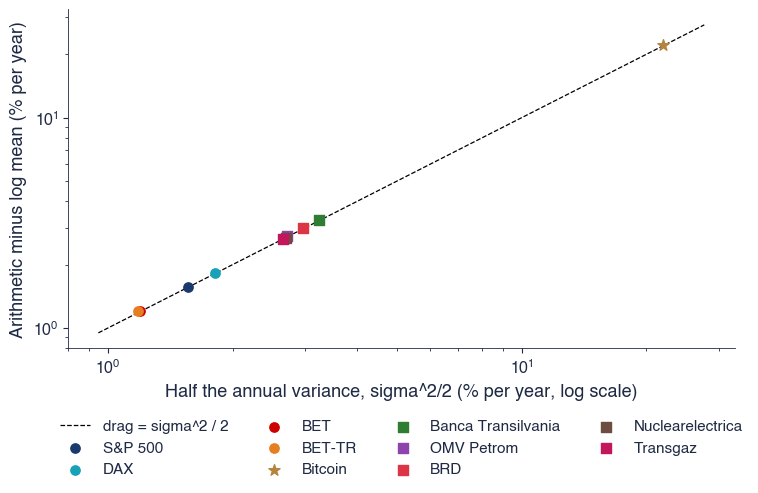

In [27]:
fig_vol_drag(perf, save=False)

## 7. AI for scientific discovery: do Sharpe ratios persist?

- Open question: is a stock with a high Sharpe ratio in one period also good in the next?
- Starter code: Sharpe ratios of six BVB stocks in two halves of the sample and the rank correlation.
- Things to check before trusting any answer, yours or an AI's: adjusted prices, the annualisation factor, the standard errors, how many windows you tried.

In [28]:
rows = {}
for k in ['tlv', 'snp', 'brd', 'tgn', 'sng', 'snn']:
    p = load_close(k, START)
    a, b = performance(p.loc[:'2020-12-31']), performance(p.loc['2020-12-31':])
    rows[LABELS[k]] = {'SR 2015-2020': a['sharpe'], 'SE 1': a['sharpe_se'], 'SR 2021-2026': b['sharpe'], 'SE 2': b['sharpe_se']}
tab = pd.DataFrame(rows).T
print('Spearman rank correlation:', round(stats.spearmanr(tab.iloc[:, 0], tab.iloc[:, 2])[0], 2))
tab.round(2)

Spearman rank correlation: -0.71


,SR 2015-2020,SE 1,SR 2021-2026,SE 2
Banca Transilvania,0.91,0.41,1.34,0.42
OMV Petrom,0.26,0.41,1.75,0.42
BRD,0.71,0.41,0.96,0.42
Transgaz,0.63,0.41,1.27,0.42
Romgaz,0.52,0.41,1.63,0.42
Nuclearelectrica,1.31,0.41,1.23,0.42
